# ARoF MP-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado\DPD"
file_path    = project_path + r"\Optuna_studies\DPD_MP"

sys.path.append(project_path)
sys.path.append(file_path)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal           import firwin, hilbert
from scipy.constants        import pi
from tqdm.notebook          import tqdm
from tabulate               import tabulate
from functools              import partial

from optic.comm.modulation  import modulateGray
from optic.comm.ofdm        import modulateOFDM, demodulateOFDM
from optic.models.channels  import linearFiberChannel
from optic.models.devices   import mzm, photodiode
from optic.comm.metrics     import fastBERcalc, theoryBER, calcEVM
from optic.dsp.core         import pnorm, signal_power, upsample, decimate, finddelay
from optic.dsp.coreGPU      import firFilter
from optic.utils            import parameters, dBm2W
from optic_private.dsp.core import calcACLR

from DPD_utils.MP_tools     import powerAmplifier, LS_solver
from DPD_utils.Optuna_utils import objective_DPD, get_pareto

import torch as th

import optuna
from optuna.trial import TrialState

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [4]:
device = "cuda"
includeMemory = True

# Parâmetros de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 32                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.modOrder = 64                # Ordem da modulação
paramOFDM.modType  = 'qam'             # Tipo de modulação
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.G    = 32                   # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz
paramOFDM.Ni = Ni

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(paramOFDM.modOrder) )    # Taxa de transmissão de símbolos
Fs  = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 50
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(paramOFDM.modOrder))))

symbTx = modulateGray(bits, paramOFDM.modOrder, paramOFDM.modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [5]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, len(sigTx))*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [6]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{paramOFDM.modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 27.74 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.87 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [7]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi/2
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 7.5e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

In [8]:
# Sinal RF
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )
G_1 = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= G_1

# Sinal óptico
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

# Sinal elétrico (fotocorrente)
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

# Sinal elétrico pós-FPF
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

# Sina elétrico pós-PA
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
G_2 = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= G_2

sigRx = powerAmplifier(sigRx)

sigRx_PA = sigRx.copy()
G_3 = 10**( np.log10(signal_power(sigTx)/signal_power(sigRx_PA))/2)
sigRx_PA *= G_3

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
#sigRx = firFilter(hlp, sigRx)

delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

In [9]:
# Param RoF
paramRoF = parameters()
paramRoF.SpS = SpS
paramRoF.Fs  = Fs
paramRoF.Rs  = Rs
paramRoF.G_list = (G_1, G_2, G_3)
paramRoF.paramMZM = paramMZM
paramRoF.paramChannel = paramChannel
paramRoF.paramRF = paramRF
paramRoF.paramPD = paramPD

### 3 Preparação do conjunto de dados de treinamento

In [10]:
SpS_nn = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_nn

hlp = firwin(numtaps, SpS_nn*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec).ravel()
sigIn  = decimate(pnorm(sigRx_PA), paramDec).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [11]:
paramILA = parameters()

paramILA.DPD = "MP"

paramILA.M = 4
paramILA.P = 3

paramILA.N = 20_000
paramILA.numIter = 5

paramILA.mu  = 1e-3
paramILA.lbd = 0.9999
paramILA.S   = np.eye(paramILA.P*paramILA.M, dtype = complex)*5e-2

paramILA.SpS_DPD = 4
paramILA.alg = "RLS"
paramILA.a_kl = None
paramILA.directLearn = False

paramILA.pgrsBar    = False
paramILA.showMSE    = False
paramILA.storeCoeff = True

In [12]:
attr_test = parameters()
attr_test.symbTx    = symbTx
attr_test.paramRoF  = paramRoF
attr_test.paramOFDM = paramOFDM
attr_test.paramDPD  = paramILA

attr_train = parameters()
attr_train.sigIn  = sigIn
attr_train.sigRef = sigRef
attr_train.paramDPD = paramILA

objective_ILA = partial(objective_DPD, attr_test = attr_test, attr_train = attr_train, metrics = ["EVM", "NFLOPs"], model_path = file_path + "\\ILA\\Study_1\\Models")

In [ ]:
n_trials  = 50
n_studies = 1
timeout = 60*60*15
save = True

for i in range(n_studies):
    print(f"Study {i+1}:")
    study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.TPESampler())
    study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)
    
    complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
    n_complete_trials = len(complete_trials)
    
    study_P      = np.zeros(n_complete_trials)
    study_M      = np.zeros(n_complete_trials)
    
    study_EVM    = np.zeros(n_complete_trials)
    #study_ACLR   = np.zeros(n_complete_trials)
    study_NFLOPs = np.zeros(n_complete_trials)
    
    for j in range(n_complete_trials):
        trials_params   = complete_trials[j].params
        study_EVM[j]    = complete_trials[j].values[0]
        study_ACLR[j]   = complete_trials[j].values[1]
        #study_NFLOPs[j] = complete_trials[j].values[1]
        
        study_P[j] = trials_params["P"]
        study_M[j] = trials_params["M"]
    
    if save:
        np.savetxt(file_path + f'\\ILA\\Study_{i+1}\\Parameters\\P.txt', study_P, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i+1}\\Parameters\\M.txt', study_M, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i+1}\\Results\\ACLR.txt', study_ACLR, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i+1}\\Results\\EVM.txt', study_EVM, fmt = '%f')
        #np.savetxt(file_path + f'\\ILA\\Study_{i+1}\\Results\\NFLOps.txt', study_NFLOPs, fmt = '%f')

In [ ]:
pareto_solutions = get_pareto(EVM, ACLR, n_trials)
    
fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(ACLR, EVM, color = "gray", alpha = 0.6)
axs.plot(pareto_solutions[:,1], pareto_solutions[:,0], "-o", color = "r")

#axs.set_xlim(0, 3e3)
#axs.set_ylim(3, 10)
axs.set_xlabel("ACLR", fontsize = 18)
axs.set_ylabel("EVM [%]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs.grid()
plt.tight_layout()
plt.savefig(file_path + "\plot_pareto_EVM.png")

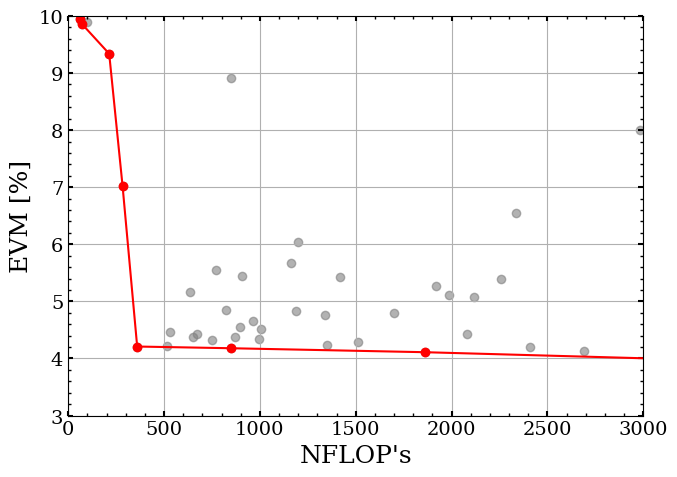

In [30]:
trials_pareto = study_ILA.best_trials
EVM_pareto    = np.array([trials_pareto[i].values[0] for i in range(len(trials_pareto))])
NFLOPs_pareto = np.array([trials_pareto[i].values[1] for i in range(len(trials_pareto))])

pair_pareto = [ (NFLOPs_pareto[i], EVM_pareto[i]) for i in range(len(trials_pareto)) ]
pair_pareto.sort()
pair_pareto = np.array(pair_pareto)

fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(study_NFLOPs, study_EVM, color = "gray", alpha = 0.6)
axs.plot(pair_pareto[:,0], pair_pareto[:,1], "-o", color = "r")

axs.set_xlim(0, 3e3)
axs.set_ylim(3, 10)
axs.set_xlabel("NFLOP's", fontsize = 18)
axs.set_ylabel("EVM [%]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs.grid()
plt.tight_layout()
plt.savefig(file_path + "\\Plots\\plot_pareto_EVM.png")

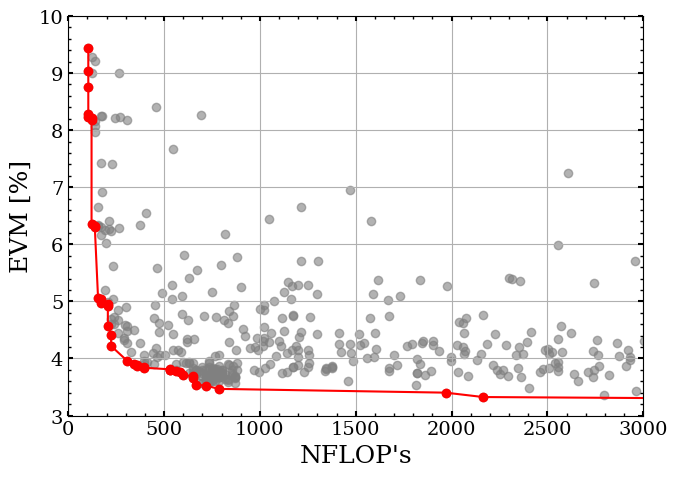

In [30]:
pareto_solutions = get_pareto(EVM, NFLOPs, n_trials)
    
fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(NFLOPs, EVM, color = "gray", alpha = 0.6)
axs.plot(pareto_solutions[:,1], pareto_solutions[:,0], "-o", color = "r")

axs.set_xlim(0, 3e3)
axs.set_ylim(3, 10)
axs.set_xlabel("NFLOP's", fontsize = 18)
axs.set_ylabel("EVM [%]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs.grid()
plt.tight_layout()
plt.savefig(file_path + "\plot_pareto_EVM.png")

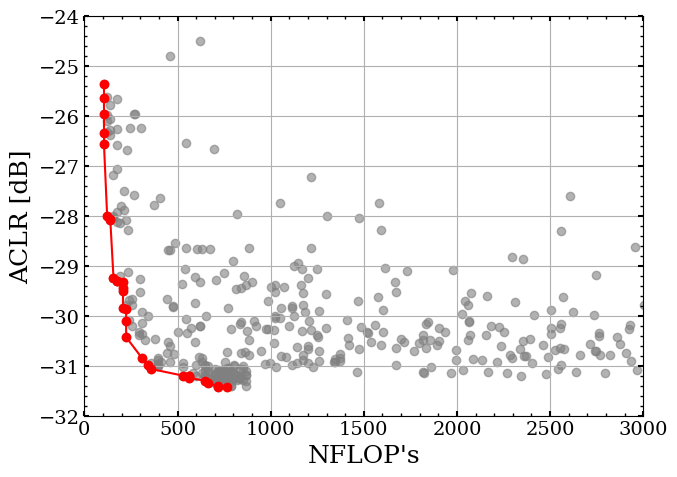

In [28]:
pareto_solutions = get_pareto(ACLR, NFLOPs, n_trials)

fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(NFLOPs, ACLR, color = "gray", alpha = 0.6)
axs.plot(pareto_solutions[:,1], pareto_solutions[:,0], "-o", color = "r")

axs.set_xlim(0, 3e3)
axs.set_ylim(-32, -24)
axs.set_xlabel("NFLOP's", fontsize = 18)
axs.set_ylabel("ACLR [dB]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs.grid()
plt.tight_layout()
plt.savefig(file_path + "\\Plots\\plot_pareto_ACLR.png")

In [31]:
pair_pareto

array([[6.40000000e+01, 9.94910144e+00],
       [7.10000000e+01, 9.86340521e+00],
       [2.14000000e+02, 9.33893483e+00],
       [2.84000000e+02, 7.01561495e+00],
       [3.60000000e+02, 4.20974114e+00],
       [8.49000000e+02, 4.17983917e+00],
       [1.86300000e+03, 4.11015529e+00],
       [4.17200000e+03, 3.89468670e+00],
       [5.29900000e+03, 3.40705846e+00]])

In [32]:
for tt in trials_pareto:
    print(tt.values)
    print(tt.params)

[3.894686695633435, 4172.0]
{'Nlayers': 2, 'N1': 37, 'N2': 33, 'N3': 3, 'Ntaps': 4, 'K': 3}
[3.4070584584469628, 5299.0]
{'Nlayers': 2, 'N1': 39, 'N2': 44, 'N3': 29, 'Ntaps': 4, 'K': 3}
[4.209741136994754, 360.0]
{'Nlayers': 1, 'N1': 20, 'N2': 2, 'N3': 8, 'Ntaps': 2, 'K': 1}
[4.179839174446584, 849.0]
{'Nlayers': 2, 'N1': 16, 'N2': 15, 'N3': 3, 'Ntaps': 2, 'K': 2}
[4.110155288262921, 1863.0]
{'Nlayers': 2, 'N1': 30, 'N2': 9, 'N3': 18, 'Ntaps': 4, 'K': 3}
[9.338934831052912, 214.0]
{'Nlayers': 1, 'N1': 6, 'N2': 30, 'N3': 11, 'Ntaps': 4, 'K': 1}
[9.863405214455913, 71.0]
{'Nlayers': 1, 'N1': 3, 'N2': 10, 'N3': 2, 'Ntaps': 2, 'K': 1}
[9.949101443435659, 64.0]
{'Nlayers': 1, 'N1': 2, 'N2': 2, 'N3': 21, 'Ntaps': 2, 'K': 2}
[7.015614946542209, 284.0]
{'Nlayers': 2, 'N1': 12, 'N2': 2, 'N3': 15, 'Ntaps': 2, 'K': 2}


### 5 - Arquitetura de Aprendizado Direto (DLA)

In [16]:
K = 3
L = 2

a_kl   = LS_solver(sigRef[0:50_000], sigIn[0:50_000], K, L)

In [17]:
paramDLA = parameters()

paramDLA.DPD = "MP"

paramDLA.M = 4
paramDLA.P = 3

paramDLA.N = 20_000
paramDLA.numIter = 5

paramDLA.mu  = 0.5
paramDLA.lbd = 0.9999
paramDLA.S   = np.eye(paramDLA.P*paramDLA.M, dtype = complex)*5e-2

paramDLA.SpS_DPD = 4
paramDLA.alg = "NFxRLS"
paramDLA.a_kl = a_kl
paramDLA.directLearn = True

paramDLA.pgrsBar    = False
paramDLA.showMSE    = False
paramDLA.storeCoeff = True

In [19]:
attr_test = parameters()
attr_test.symbTx    = symbTx
attr_test.paramRoF  = paramRoF
attr_test.paramOFDM = paramOFDM
attr_test.paramDPD  = paramILA

attr_train = parameters()
attr_train.sigIn  = sigIn
attr_train.sigRef = sigRef
attr_train.paramDPD = paramILA

objective_DLA = partial(objective_DPD, attr_test = attr_test, attr_train = attr_train, metrics = ["EVM", "NFLOPs"], model_path = file_path + "\\ILA\\Study_1\\Models")

In [ ]:
n_trials  = 50
n_studies = 1
timeout = 60*60*15
save = True

for i in range(n_studies):
    print(f"Study {i+1}:")
    study_DLA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.TPESampler())
    study_DLA.optimize(objective_DLA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)
    
    complete_trials   = study_DLA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
    n_complete_trials = len(complete_trials)
    
    study_P = np.zeros(n_complete_trials)
    study_M = np.zeros(n_complete_trials)
    
    study_EVM    = np.zeros(n_complete_trials)
    study_ACLR   = np.zeros(n_complete_trials)
    #study_NFLOPs = np.zeros(n_complete_trials)
    
    for j in range(n_complete_trials):
        trials_params    = complete_trials[j].params
        study_EVM[j]     = complete_trials[j].values[0]
        study_ACLR[j]    = complete_trials[j].values[1]
        #study_NFLOPs[j]  = complete_trials[j].values[1]
        
        study_P[j] = trials_params["P"]
        study_M[j] = trials_params["M"]
        
    if save:
        np.savetxt(file_path + f'\\DLA\\Study_{i+1}\\Parameters\\P.txt', study_P, fmt = '%f')
        np.savetxt(file_path + f'\\DLA\\Study_{i+1}\\Parameters\\M.txt', study_M, fmt = '%f')
        #np.savetxt(file_path + f'\\DLA\\Study_{i+1}\\Results\\ACLR.txt', study_ACLR, fmt = '%f')
        np.savetxt(file_path + f'\\DLA\\Study_{i+1}\\Results\\EVM.txt', study_EVM, fmt = '%f')
        np.savetxt(file_path + f'\\DLA\\Study_{i+1}\\Results\\NFLOps.txt', study_NFLOPs, fmt = '%f')